In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df = pd.read_csv(r"C:\Users\adin\Downloads\retail_sales_dataset.csv")
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [7]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='str')

In [8]:
df.info

<bound method DataFrame.info of      Transaction ID        Date Customer ID  Gender  Age Product Category  \
0                 1  2023-11-24     CUST001    Male   34           Beauty   
1                 2  2023-02-27     CUST002  Female   26         Clothing   
2                 3  2023-01-13     CUST003    Male   50      Electronics   
3                 4  2023-05-21     CUST004    Male   37         Clothing   
4                 5  2023-05-06     CUST005    Male   30           Beauty   
..              ...         ...         ...     ...  ...              ...   
995             996  2023-05-16     CUST996    Male   62         Clothing   
996             997  2023-11-17     CUST997    Male   52           Beauty   
997             998  2023-10-29     CUST998  Female   23           Beauty   
998             999  2023-12-05     CUST999  Female   36      Electronics   
999            1000  2023-04-12    CUST1000    Male   47      Electronics   

     Quantity  Price per Unit  Total Amount

In [11]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [17]:
df.drop_duplicates()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150


In [22]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [18]:
df['Age'].mean()

np.float64(41.392)

In [19]:
df['Price per Unit'].median()

np.float64(50.0)

In [20]:
df['Gender'].mode()

0    Female
Name: Gender, dtype: str

In [21]:
df['Total Amount'].std()

np.float64(559.997631555123)

In [16]:
plt.figure(figsize=(10,5))
Total Amount.plot(marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.show()

SyntaxError: invalid syntax (3621208766.py, line 2)

In [14]:
top_customer = df.groupby('Customer ID')['Price per Unit'].sum()
top_customers = top_customer.sort_values(ascending=False)

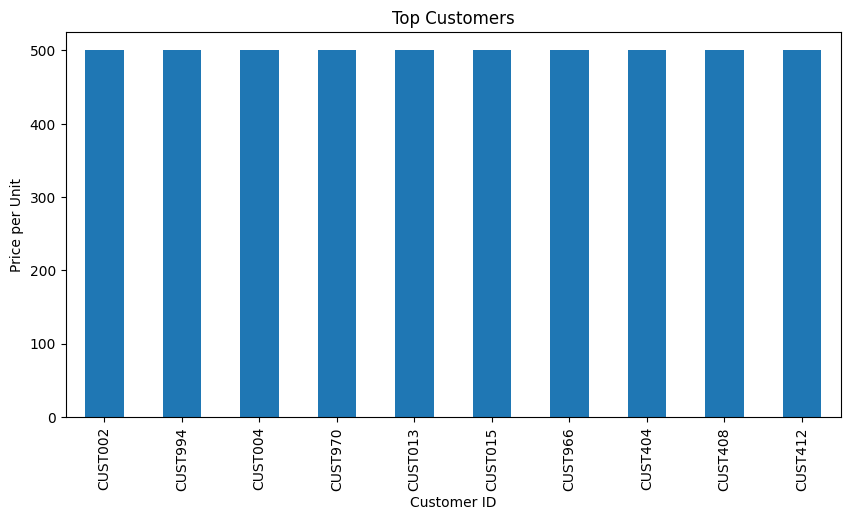

In [15]:
plt.figure(figsize=(10,5))

top_customers.head(10).plot(kind='bar')

plt.title("Top Customers")
plt.xlabel("Customer ID")
plt.ylabel("Price per Unit")

plt.show()

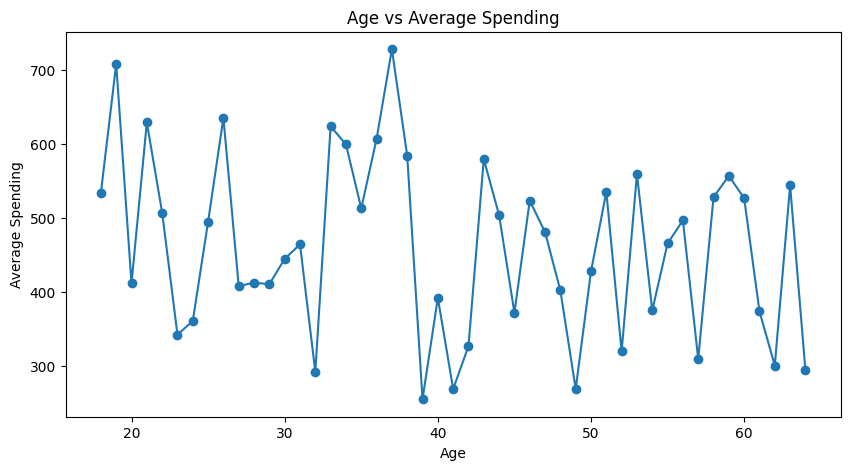

In [17]:
# Age Wise Average Spending
age_sales = df.groupby('Age')['Total Amount'].mean()

plt.figure(figsize=(10,5))

age_sales.plot(marker='o')

plt.title("Age vs Average Spending")
plt.xlabel("Age")
plt.ylabel("Average Spending")

plt.show()

In [18]:
category_sales = df.groupby('Product Category')['Total Amount'].sum()

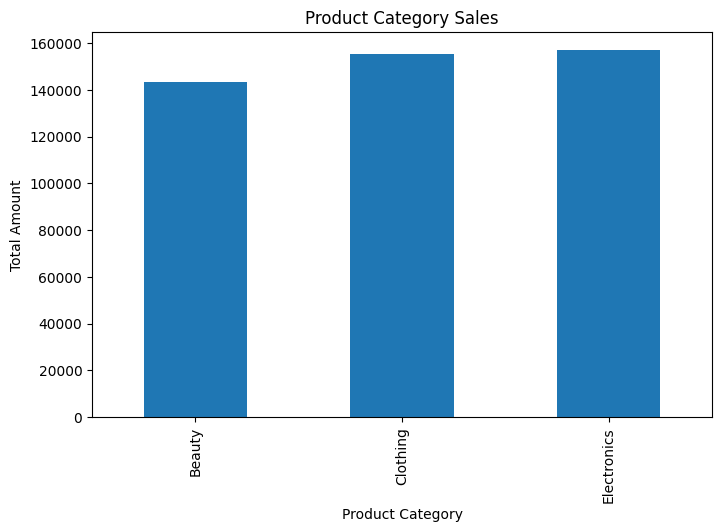

In [20]:
plt.figure(figsize=(8,5))

category_sales.plot(kind='bar')

plt.title("Product Category Sales")
plt.xlabel("Product Category")
plt.ylabel("Total Amount")

plt.show()

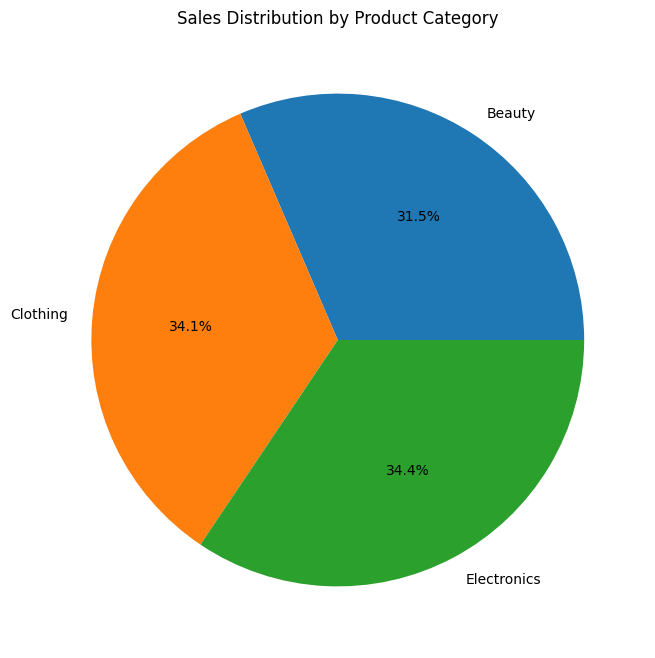

In [21]:
plt.figure(figsize=(8,8))

plt.pie(
    category_sales,
    labels=category_sales.index,
    autopct='%1.1f%%'
)

plt.title("Sales Distribution by Product Category")

plt.show()


CORRELATION MATRIX
                Transaction ID       Age  Quantity  Price per Unit  \
Transaction ID        1.000000  0.065191 -0.026623       -0.060837   
Age                   0.065191  1.000000 -0.023737       -0.038423   
Quantity             -0.026623 -0.023737  1.000000        0.017501   
Price per Unit       -0.060837 -0.038423  0.017501        1.000000   
Total Amount         -0.075034 -0.060568  0.373707        0.851925   

                Total Amount  
Transaction ID     -0.075034  
Age                -0.060568  
Quantity            0.373707  
Price per Unit      0.851925  
Total Amount        1.000000  


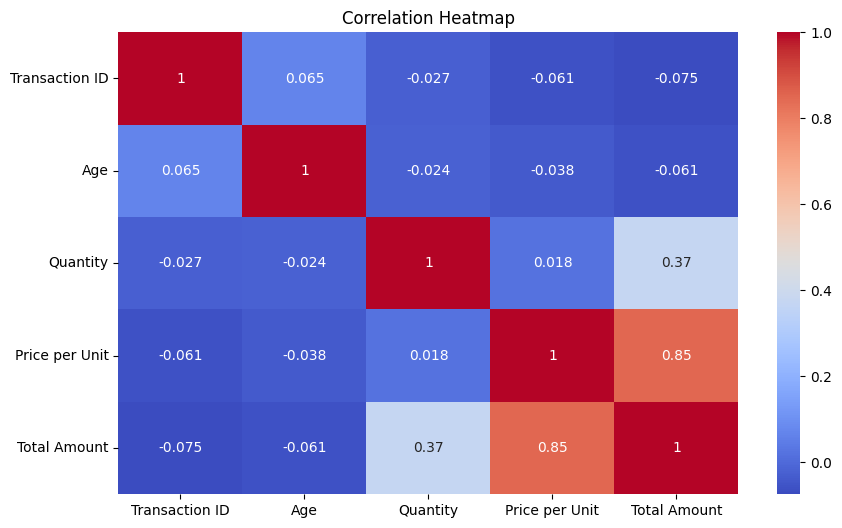

In [22]:
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

print("\nCORRELATION MATRIX")
print(correlation)

# Heatmap
plt.figure(figsize=(10,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [23]:
highest_sale = df.loc[df['Total Amount'].idxmax()]

print("\nHIGHEST SALES RECORD")
print(highest_sale)



HIGHEST SALES RECORD
Transaction ID               15
Date                 2023-01-16
Customer ID             CUST015
Gender                   Female
Age                          42
Product Category    Electronics
Quantity                      4
Price per Unit              500
Total Amount               2000
Name: 14, dtype: object


In [24]:
lowest_sale = df.loc[df['Total Amount'].idxmin()]

print("\nLOWEST SALES RECORD")
print(lowest_sale)


LOWEST SALES RECORD
Transaction ID              44
Date                2023-02-19
Customer ID            CUST044
Gender                  Female
Age                         22
Product Category      Clothing
Quantity                     1
Price per Unit              25
Total Amount                25
Name: 43, dtype: object


In [25]:
print("""

================ RECOMMENDATIONS ================

1. Increase stock for high-selling categories.

2. Focus marketing campaigns during high-sales months.

3. Provide offers to loyal customers.

4. Improve low-performing product categories.

5. Target customer groups with higher spending behavior.

================================================

""")




================ RECOMMENDATIONS ================

1. Increase stock for high-selling categories.

2. Focus marketing campaigns during high-sales months.

3. Provide offers to loyal customers.

4. Improve low-performing product categories.

5. Target customer groups with higher spending behavior.



